In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#Load Dataset
df = pd.read_csv("C:/Users/sagar/Downloads/Student_Performance_Dataset (2).csv")

df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


In [3]:
#Display Dataset Information
df.shape

(5000, 16)

In [4]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Class', 'Study_Hours_Per_Day',
       'Attendance_Percentage', 'Parental_Education', 'Internet_Access',
       'Extracurricular_Activities', 'Math_Score', 'Science_Score',
       'English_Score', 'Previous_Year_Score', 'Final_Percentage',
       'Performance_Level', 'Pass_Fail'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

In [6]:
df.describe()

,Age,Class,Study_Hours_Per_Day,Attendance_Percentage,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,16.508800,10.496400,3.287260,74.919800,67.754800,66.895400,67.782800,67.282200,67.477656
std,1.718637,1.106812,1.587979,14.673842,18.724487,19.141195,19.248473,16.157511,10.964081
min,14.000000,9.000000,0.500000,50.000000,35.000000,35.000000,35.000000,40.000000,36.330000
25%,15.000000,10.000000,1.900000,62.000000,52.000000,50.000000,51.000000,53.000000,59.670000
50%,17.000000,10.000000,3.300000,75.000000,68.000000,67.000000,68.000000,67.000000,67.330000
75%,18.000000,11.000000,4.700000,88.000000,84.000000,83.000000,85.000000,81.000000,75.330000
max,19.000000,12.000000,6.000000,100.000000,100.000000,100.000000,100.000000,95.000000,98.330000


In [7]:
#Check Missing Values
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Class                         0
Study_Hours_Per_Day           0
Attendance_Percentage         0
Parental_Education            0
Internet_Access               0
Extracurricular_Activities    0
Math_Score                    0
Science_Score                 0
English_Score                 0
Previous_Year_Score           0
Final_Percentage              0
Performance_Level             0
Pass_Fail                     0
dtype: int64

In [8]:
df.fillna(df.mode().iloc[0], inplace=True)

In [9]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

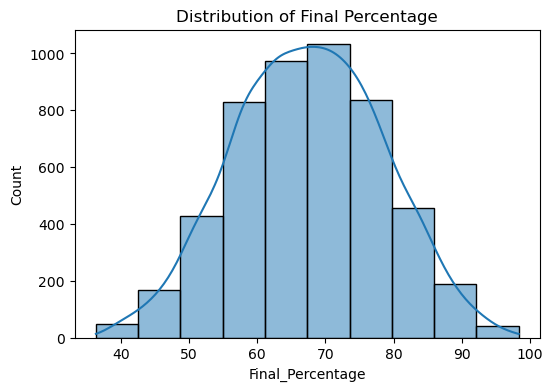

In [11]:
#Exploratory Data Analysis (EDA)
plt.figure(figsize=(6,4))
sns.histplot(df["Final_Percentage"], bins=10, kde=True)
plt.title("Distribution of Final Percentage")
plt.show()

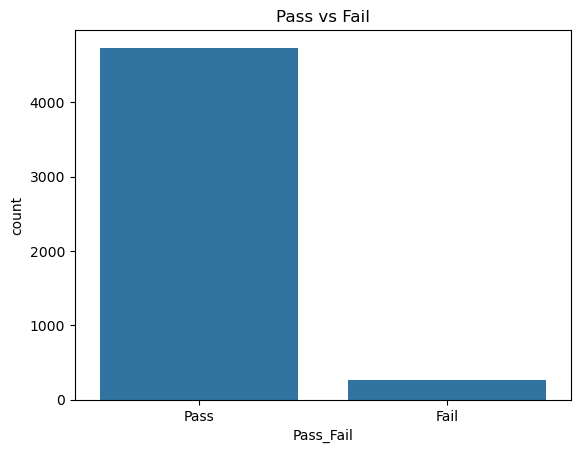

In [12]:
#Pass/Fail Count
sns.countplot(x="Pass_Fail", data=df)
plt.title("Pass vs Fail")
plt.show()

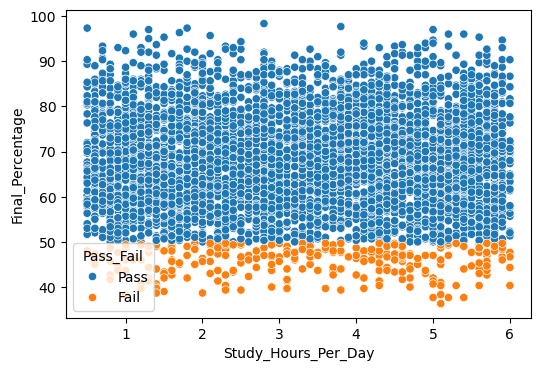

In [13]:
#Study Hours vs Final Percentage
plt.figure(figsize=(6,4))
sns.scatterplot(x="Study_Hours_Per_Day",
                y="Final_Percentage",
                hue="Pass_Fail",
                data=df)

plt.show()

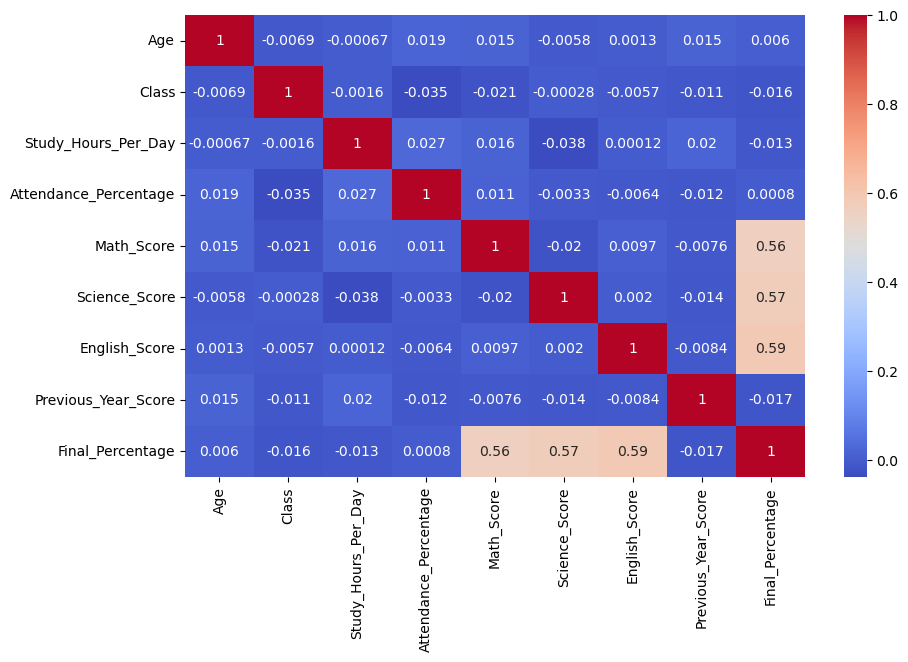

In [14]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [15]:
#Encode Categorical Columns
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,0,15,1,12,1.0,65,2,0,0,40,39,72,81,50.33,0,1
1,1,19,0,9,1.6,58,0,0,1,80,44,35,47,53.00,0,1
2,2,14,0,12,3.6,64,1,1,1,83,73,59,58,71.67,2,1
3,3,18,0,9,5.5,68,2,1,0,68,48,77,54,64.33,0,1
4,4,14,1,10,5.0,80,1,1,0,41,46,36,68,41.00,3,0


In [16]:
#Select Features and Target
y = df["Pass_Fail"]

In [17]:
X = df.drop(["Student_ID",
             "Pass_Fail",
             "Performance_Level"], axis=1)

In [18]:
#Feature Scaling
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [19]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
#Train Logistic Regression Model
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
#Predict
y_pred = model.predict(X_test)

In [22]:
#Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.997


In [23]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 57   3]
 [  0 940]]


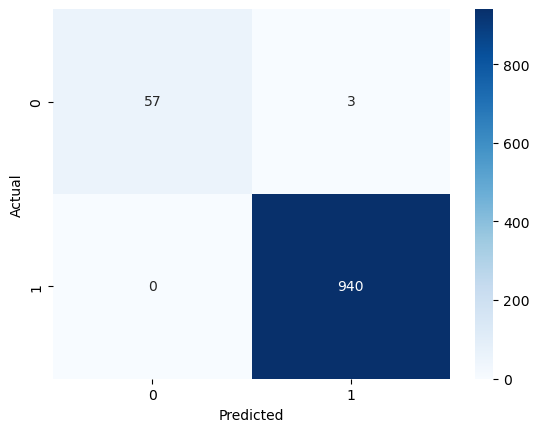

In [24]:
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        60
           1       1.00      1.00      1.00       940

    accuracy                           1.00      1000
   macro avg       1.00      0.97      0.99      1000
weighted avg       1.00      1.00      1.00      1000



In [31]:
#Predict for a New Student
new_student = [[
16,
0,
1,
4,
85,
2,
1,
1,
78,
82,
75,
80,
79
]]

In [32]:
new_student = scaler.transform(new_student)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Predicted Result: Pass")
else:
    print("Predicted Result: Fail")

Predicted Result: Pass
